# Purpose

The purpose of this project is to build a model to predict if someone has depresssion. A good accuracy score will tell me if I succeeded. A good model will allow us to apply interpretations to our discovered coefficients.

# Imports

In [47]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import classification_report, confusion_matrix

# Data Loading

In [48]:
df = pd.read_csv('/content/train.csv')

df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 140700 entries, 0 to 140699
Data columns (total 20 columns):
 #   Column                                 Non-Null Count   Dtype  
---  ------                                 --------------   -----  
 0   id                                     140700 non-null  int64  
 1   Name                                   140700 non-null  object 
 2   Gender                                 140700 non-null  object 
 3   Age                                    140700 non-null  float64
 4   City                                   140700 non-null  object 
 5   Working Professional or Student        140700 non-null  object 
 6   Profession                             104070 non-null  object 
 7   Academic Pressure                      27897 non-null   float64
 8   Work Pressure                          112782 non-null  float64
 9   CGPA                                   27898 non-null   float64
 10  Study Satisfaction                     27897 non-null   

# Data Cleaning

In [49]:
summary_table = df.groupby('Degree').agg(
    Count=('Degree', 'size')
)

summary_table

,Count
Degree,
0,1
20,1
24,1
29,1
5.56,1
...,...
Unite,1
Veda,1
Vivaan,1


In [50]:
summary_table = df.groupby('Profession').agg(
    Count=('Profession', 'size')
)

summary_table

,Count
Profession,
Academic,5
Accountant,1339
Analyst,1
Architect,4370
B.Com,1
...,...
Unveil,1
Visakhapatnam,1
Working Professional,1


In [51]:
# Drop unuseful columns
columns_to_drop_initial = ['Name', 'City', 'CGPA', 'Degree', 'Profession']
#CGPA is dropped because there's no comparable value for professionals
#Degree and Profession are dropped because there are too many options to feature engineer for a logistic regression model
print(f"Dropping columns: {columns_to_drop_initial}")
df_cleaned = df.drop(columns=columns_to_drop_initial)

Dropping columns: ['Name', 'City', 'CGPA', 'Degree', 'Profession']


Shape after NA drops: (140671, 15)


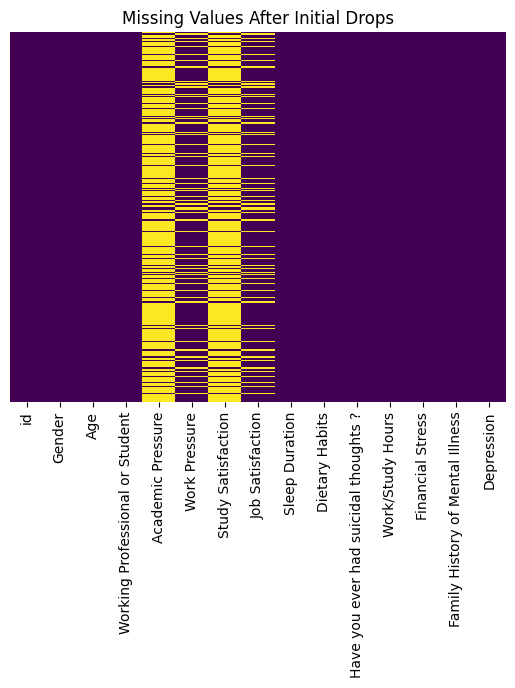

In [52]:
df_cleaned = df_cleaned.dropna(subset=['Academic Pressure', 'Work Pressure'], how='all')
df_cleaned = df_cleaned.dropna(subset=['Study Satisfaction', 'Job Satisfaction'], how='all')
print(f"Shape after NA drops: {df_cleaned.shape}")

sns.heatmap(df_cleaned.isnull(), yticklabels=False, cbar=False, cmap='viridis')
plt.title("Missing Values After Initial Drops")
plt.show()

In [66]:
summary_table = df.groupby('Dietary Habits').agg(
    Count=('Dietary Habits', 'size')
)

summary_table

,Count
Dietary Habits,
1.0,1
2,1
3,1
BSc,1
Class 12,1
Electrician,1
Gender,1
Healthy,44741
Hormonal,1


In [67]:
summary_table = df.groupby('Sleep Duration').agg(
    Count=('Sleep Duration', 'size')
)

summary_table

,Count
Sleep Duration,
1-2 hours,1
1-3 hours,1
1-6 hours,4
10-11 hours,2
10-6 hours,1
2-3 hours,5
3-4 hours,12
3-6 hours,1
35-36 hours,1


In [53]:
# Clean 'Dietary Habits'
allowed_habits = ['Healthy', 'Moderate', 'Unhealthy']
df_cleaned = df_cleaned[df_cleaned['Dietary Habits'].isin(allowed_habits)]

# Clean 'Sleep Duration'
allowed_sleep = ["More than 8 hours", "Less than 5 hours", "7-8 hours", "5-6 hours"]
df_cleaned = df_cleaned[df_cleaned['Sleep Duration'].isin(allowed_sleep)]

In [68]:
df_cleaned.info()

<class 'pandas.core.frame.DataFrame'>
Index: 140561 entries, 0 to 140699
Data columns (total 15 columns):
 #   Column                                 Non-Null Count   Dtype  
---  ------                                 --------------   -----  
 0   id                                     140561 non-null  int64  
 1   Gender                                 140561 non-null  object 
 2   Age                                    140561 non-null  float64
 3   Working Professional or Student        140561 non-null  object 
 4   Academic Pressure                      27861 non-null   float64
 5   Work Pressure                          112700 non-null  float64
 6   Study Satisfaction                     27861 non-null   float64
 7   Job Satisfaction                       112702 non-null  float64
 8   Sleep Duration                         140561 non-null  object 
 9   Dietary Habits                         140561 non-null  object 
 10  Have you ever had suicidal thoughts ?  140561 non-null  objec

In [ ]:
# Drop rows with missing 'Financial Stress'
df_cleaned = df_cleaned.dropna(subset=['Financial Stress'], how='all')

# Feature Engineering

<class 'pandas.core.frame.DataFrame'>
Index: 140561 entries, 0 to 140699
Data columns (total 13 columns):
 #   Column                                 Non-Null Count   Dtype  
---  ------                                 --------------   -----  
 0   id                                     140561 non-null  int64  
 1   Gender                                 140561 non-null  object 
 2   Age                                    140561 non-null  float64
 3   Working Professional or Student        140561 non-null  object 
 4   Sleep Duration                         140561 non-null  object 
 5   Dietary Habits                         140561 non-null  object 
 6   Have you ever had suicidal thoughts ?  140561 non-null  object 
 7   Work/Study Hours                       140561 non-null  float64
 8   Financial Stress                       140561 non-null  float64
 9   Family History of Mental Illness       140561 non-null  object 
 10  Depression                             140561 non-null  int64

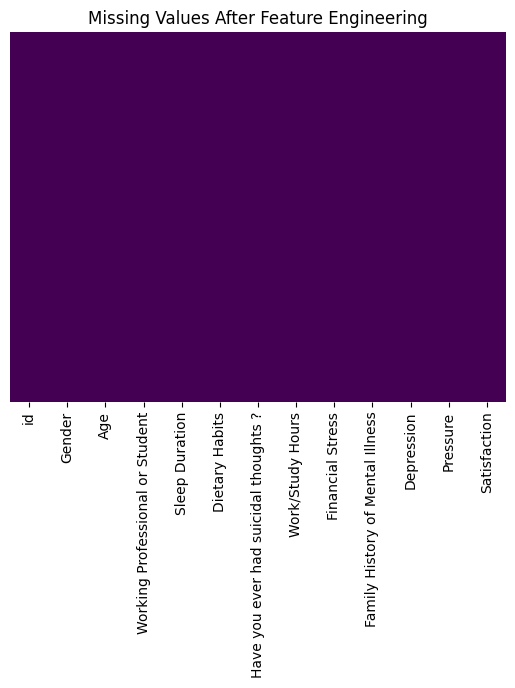

In [54]:
# Make a copy of df_cleaned to avoid SettingWithCopyWarning
df_engineered = df_cleaned.copy()

# Combine Pressure and Satisfaction columns
df_engineered['Pressure'] = df_engineered['Academic Pressure'].combine_first(df_engineered['Work Pressure'])
df_engineered['Satisfaction'] = df_engineered['Study Satisfaction'].combine_first(df_engineered['Job Satisfaction'])

# Drop original uncombined columns
columns_to_drop_combined = ['Academic Pressure', 'Work Pressure', 'Study Satisfaction', 'Job Satisfaction']
df_engineered = df_engineered.drop(columns=columns_to_drop_combined)

df_engineered.info()

#Visualize missing values
sns.heatmap(df_engineered.isnull(), yticklabels=False, cbar=False, cmap='viridis')
plt.title("Missing Values After Feature Engineering")
plt.show()

# Feature Encoding

In [55]:
gender_map = {'Female': 0, 'Male': 1}
work_map = {'Student': 0, 'Working Professional': 1} # Note: Original code had 0 for Prof, 1 for Student. Swapped for potential interpretation ease. Adjust if needed.
diet_map = {'Unhealthy': 1, 'Moderate': 2, 'Healthy': 3}
sleep_map = {'Less than 5 hours': 4.0, '5-6 hours': 5.5, '7-8 hours': 7.5, 'More than 8 hours': 9.0} # Use floats for consistency
yes_no_map = {'No': 0, 'Yes': 1}

df_encoded = df_engineered.copy() # Work on a new copy
df_encoded['Gender'] = df_encoded['Gender'].map(gender_map)
df_encoded['Working Professional or Student'] = df_encoded['Working Professional or Student'].map(work_map)
df_encoded['Dietary Habits'] = df_encoded['Dietary Habits'].map(diet_map)
df_encoded['Sleep Duration'] = df_encoded['Sleep Duration'].map(sleep_map)
df_encoded['Have you ever had suicidal thoughts ?'] = df_encoded['Have you ever had suicidal thoughts ?'].map(yes_no_map)
df_encoded['Family History of Mental Illness'] = df_encoded['Family History of Mental Illness'].map(yes_no_map)


In [56]:
df_encoded = df_encoded.rename(columns={
    'Have you ever had suicidal thoughts ?': 'Suicidal Thoughts',
    'Gender': 'F-M',
    'Working Professional or Student': 'Student-Professional'
})

df_encoded.info()

<class 'pandas.core.frame.DataFrame'>
Index: 140561 entries, 0 to 140699
Data columns (total 13 columns):
 #   Column                            Non-Null Count   Dtype  
---  ------                            --------------   -----  
 0   id                                140561 non-null  int64  
 1   F-M                               140561 non-null  int64  
 2   Age                               140561 non-null  float64
 3   Student-Professional              140561 non-null  int64  
 4   Sleep Duration                    140561 non-null  float64
 5   Dietary Habits                    140561 non-null  int64  
 6   Suicidal Thoughts                 140561 non-null  int64  
 7   Work/Study Hours                  140561 non-null  float64
 8   Financial Stress                  140561 non-null  float64
 9   Family History of Mental Illness  140561 non-null  int64  
 10  Depression                        140561 non-null  int64  
 11  Pressure                          140561 non-null  float6

# Final Preparations

In [57]:
# Drop non-feature column
df_final = df_encoded.drop(['id'], axis=1)
print(f"Final columns for modeling: {list(df_final.columns)}")

X = df_final.drop('Depression', axis=1)
y = df_final['Depression']

print(f"Features shape: {X.shape}")
print(f"Target shape: {y.shape}")

Final columns for modeling: ['F-M', 'Age', 'Student-Professional', 'Sleep Duration', 'Dietary Habits', 'Suicidal Thoughts', 'Work/Study Hours', 'Financial Stress', 'Family History of Mental Illness', 'Depression', 'Pressure', 'Satisfaction']
Features shape: (140561, 11)
Target shape: (140561,)


# Modeling

In [58]:
# Split data into training and testing
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.30, random_state=101)

# Scale features to find coefficients without timeout
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Train model
logmodel = LogisticRegression(max_iter=200, random_state=101)
logmodel.fit(X_train_scaled, y_train)
predictions = logmodel.predict(X_test_scaled)

In [59]:
print(classification_report(y_test, predictions))

              precision    recall  f1-score   support

           0       0.96      0.97      0.96     34547
           1       0.84      0.81      0.82      7622

    accuracy                           0.94     42169
   macro avg       0.90      0.89      0.89     42169
weighted avg       0.94      0.94      0.94     42169



In [60]:
coefficients = logmodel.coef_[0]
feature_names = X_train.columns # Use columns from X_train before scaling
coef_df = pd.DataFrame({'Feature': feature_names, 'Coefficient': coefficients})
print(coef_df)

                             Feature  Coefficient
0                                F-M     0.002001
1                                Age    -2.063435
2               Student-Professional    -0.778324
3                     Sleep Duration    -0.265368
4                     Dietary Habits    -0.423697
5                  Suicidal Thoughts     1.242097
6                   Work/Study Hours     0.524520
7                   Financial Stress     0.768763
8   Family History of Mental Illness     0.110321
9                           Pressure     1.016485
10                      Satisfaction    -0.571941


# Coefficient Interpretation: For each standard deviation increase/decrease of feature, depression increases/decreases by X

In [61]:
# Standard deviations (for coefficients)
print("1 stdev for feature (original units):")
original_std_devs = scaler.scale_
std_dev_info = pd.DataFrame({'Feature': feature_names, 'Standard_Deviation_Value': original_std_devs})
print(std_dev_info)

# Descriptive Statistics of Final Data Used for Modeling (before scaling)
print("Descriptive stats (pre-Scaling):")
print(X_train.describe())

1 stdev for feature (original units):
                             Feature  Standard_Deviation_Value
0                                F-M                  0.497385
1                                Age                 12.377031
2               Student-Professional                  0.398788
3                     Sleep Duration                  1.913427
4                     Dietary Habits                  0.803959
5                  Suicidal Thoughts                  0.499956
6                   Work/Study Hours                  3.853259
7                   Financial Stress                  1.412388
8   Family History of Mental Illness                  0.499994
9                           Pressure                  1.402208
10                      Satisfaction                  1.405776
Descriptive stats (pre-Scaling):
                F-M           Age  Student-Professional  Sleep Duration  \
count  98392.000000  98392.000000           98392.00000    98392.000000   
mean       0.551071    

# Vizualizations

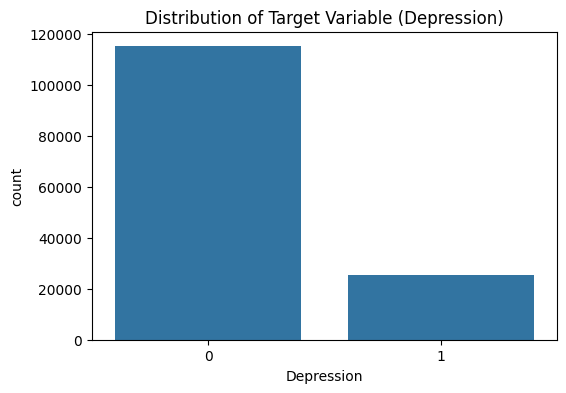

Dataset composition: ~80% Class 0 (No Depression), ~20% Class 1 (Depression)


In [62]:
plt.figure(figsize=(6, 4))
sns.countplot(x='Depression', data=df_final) # Use df_final for overall distribution
plt.title('Distribution of Target Variable (Depression)')
plt.show()
print("Dataset composition: ~80% Class 0 (No Depression), ~20% Class 1 (Depression)")

Model is better at predicting no depression than depression - a result of this unbalance -- see below

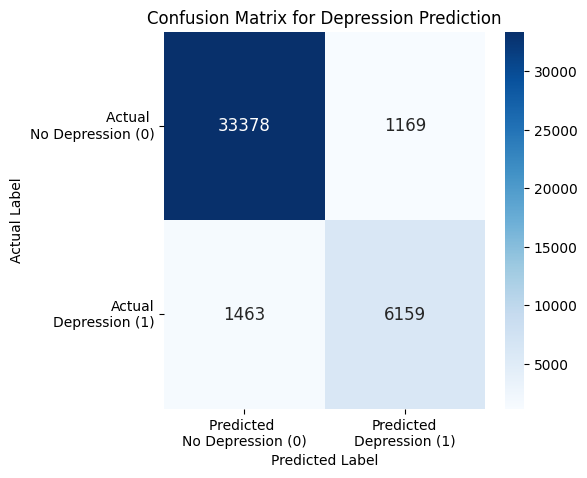

In [63]:
cm_values = confusion_matrix(y_test, predictions)
plt.figure(figsize=(6, 5))
x_labels = ['Predicted \nNo Depression (0)', 'Predicted\nDepression (1)']
y_labels = ['Actual \nNo Depression (0)', 'Actual\nDepression (1)']
sns.heatmap(cm_values, annot=True, fmt='d', cmap='Blues',
            xticklabels=x_labels, yticklabels=y_labels,
            annot_kws={"size": 12})
plt.xlabel('Predicted Label')
plt.ylabel('Actual Label')
plt.title('Confusion Matrix for Depression Prediction')
plt.xticks(rotation=0, ha='center')
plt.yticks(rotation=0, va='center')
plt.tight_layout(pad=1.5)
plt.show()

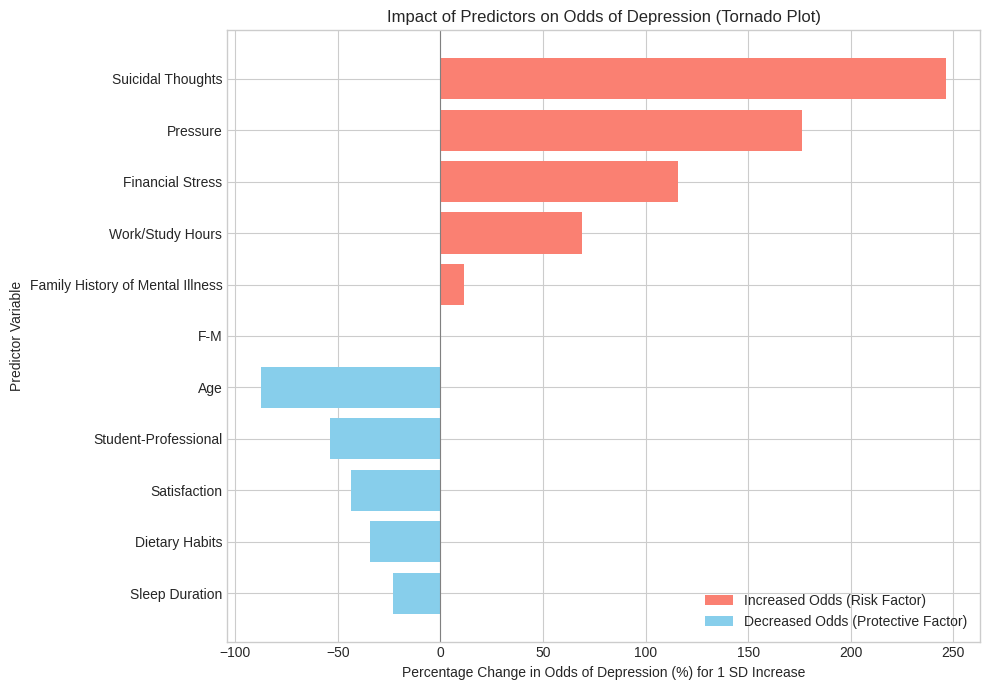

In [64]:
# Tornado Plot
coef_df['Odds_Ratio'] = np.exp(coef_df['Coefficient'])
coef_df['Percentage_Change_Odds'] = (coef_df['Odds_Ratio'] - 1) * 100

# Sort by magnitude
coef_df_sorted = coef_df.reindex(coef_df['Percentage_Change_Odds'].abs().sort_values(ascending=False).index)

positive_changes = coef_df_sorted[coef_df_sorted['Percentage_Change_Odds'] >= 0]
negative_changes = coef_df_sorted[coef_df_sorted['Percentage_Change_Odds'] < 0]

plt.style.use('seaborn-v0_8-whitegrid')
fig, ax = plt.subplots(figsize=(10, 7))
ax.barh(positive_changes['Feature'], positive_changes['Percentage_Change_Odds'],
        color='salmon', label='Increased Odds (Risk Factor)')
ax.barh(negative_changes['Feature'], negative_changes['Percentage_Change_Odds'],
        color='skyblue', label='Decreased Odds (Protective Factor)')
ax.axvline(0, color='grey', linewidth=0.8)
ax.set_xlabel('Percentage Change in Odds of Depression (%) for 1 SD Increase')
ax.set_ylabel('Predictor Variable')
ax.set_title('Impact of Predictors on Odds of Depression (Tornado Plot)')
ax.invert_yaxis()
ax.legend()
plt.tight_layout()
plt.show()

# Conclusions

* I succeeded in building a fairly good prediction model for depression
* There are many significant risk-factors for depression unrelated to lifestyle - suicidal ideation, pressure in work/school, financial stress
* A model like this could be used to support a depression prevention program - might include courses in mindfulness to reduce reported stress, financial literacy, and tips on maintaining a healthy diet on a budget

Interesting aside
* The model suggests when holding other variables constant, gender is not predictive of depression women are said to have higher incidence of depression than men, but the model suggests women just have more risk factors for depression